# Customer Segmentation & RFM Analysis
**Tools:** Python, SQL, K-Means Clustering, Power BI  
**Dataset:** Online Retail Dataset (UCI) — 100K+ transactions  
**Goal:** Compute RFM metrics, segment customers using K-Means, and identify high-value, loyal, and at-risk customers

## 1. Setup & Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn — Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

> **Download the dataset first:**  
> Go to https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci  
> Download and place `online_retail_II.xlsx` in the `data/` folder.

In [2]:
# Load both sheets and combine
df = pd.read_csv('../data/online_retail_II.csv', encoding='latin-1')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head()

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: 1,067,371 rows x 8 columns

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Dataset shape: 1,067,371 rows x 8 columns

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Cleaning

In [3]:
print(f'Shape before cleaning: {df.shape[0]:,} rows')
print(f'\nMissing values:')
print(df.isnull().sum())

# Drop rows with missing Customer ID
df.dropna(subset=['Customer ID'], inplace=True)

# Remove cancelled orders (Invoice starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero quantity and price
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Add Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Reset index
df.reset_index(drop=True, inplace=True)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'\nShape after cleaning: {df.shape[0]:,} rows')
print(f'Unique customers: {df["Customer ID"].nunique():,}')
print(f'Date range: {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')

Shape before cleaning: 1,067,371 rows

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Shape after cleaning: 805,549 rows
Unique customers: 5,878
Date range: 2009-12-01 to 2011-12-09


## 4. SQL Analysis — RFM Metric Computation

In [4]:
# Load into SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('transactions', conn, index=False, if_exists='replace')
print('Data loaded into SQLite. Table: transactions')

def run_query(query, title=''):
    result = pd.read_sql_query(query, conn)
    if title:
        print(f'\n--- {title} ---')
    return result

Data loaded into SQLite. Table: transactions


In [5]:
# Query 1: Overall business metrics
q1 = """
SELECT
    COUNT(DISTINCT "Customer ID")          AS total_customers,
    COUNT(DISTINCT Invoice)                 AS total_orders,
    ROUND(SUM(Revenue), 2)                  AS total_revenue,
    ROUND(AVG(Revenue), 2)                  AS avg_order_value
FROM transactions;
"""
run_query(q1, 'Query 1: Overall Business Metrics')


--- Query 1: Overall Business Metrics ---


,total_customers,total_orders,total_revenue,avg_order_value
0,5878,36969,17743429.18,22.03


In [6]:
# Query 2: Top 10 customers by revenue
q2 = """
SELECT
    "Customer ID",
    COUNT(DISTINCT Invoice)         AS total_orders,
    ROUND(SUM(Revenue), 2)          AS total_revenue,
    ROUND(AVG(Revenue), 2)          AS avg_order_value
FROM transactions
GROUP BY "Customer ID"
ORDER BY total_revenue DESC
LIMIT 10;
"""
run_query(q2, 'Query 2: Top 10 Customers by Revenue')


--- Query 2: Top 10 Customers by Revenue ---


,Customer ID,total_orders,total_revenue,avg_order_value
0,18102,145,608821.65,575.45
1,14646,151,528602.52,137.34
2,14156,156,313946.37,77.56
3,14911,398,295972.63,26.32
4,17450,51,246973.09,582.48
5,13694,143,196482.81,128.84
6,17511,60,175603.55,91.89
7,16446,2,168472.50,56157.50
8,16684,55,147142.77,204.93
9,12415,28,144458.37,156.00


In [7]:
# Query 3: Monthly revenue trend
q3 = """
SELECT
    SUBSTR(InvoiceDate, 1, 7)       AS month,
    COUNT(DISTINCT Invoice)         AS orders,
    COUNT(DISTINCT "Customer ID")   AS unique_customers,
    ROUND(SUM(Revenue), 2)          AS monthly_revenue
FROM transactions
GROUP BY month
ORDER BY month;
"""
run_query(q3, 'Query 3: Monthly Revenue Trend')


--- Query 3: Monthly Revenue Trend ---


,month,orders,unique_customers,monthly_revenue
0,2009-12,1512,955,686654.16
1,2010-01,1011,720,557319.06
2,2010-02,1104,772,506371.07
3,2010-03,1524,1057,699608.99
4,2010-04,1329,942,594609.19
5,2010-05,1377,966,599985.79
6,2010-06,1497,1041,639066.58
7,2010-07,1381,928,591636.74
8,2010-08,1293,911,604242.65
9,2010-09,1689,1145,831615.00


In [8]:
# Query 4: Revenue by country
q4 = """
SELECT
    Country,
    COUNT(DISTINCT "Customer ID")   AS customers,
    ROUND(SUM(Revenue), 2)          AS total_revenue,
    ROUND(100.0 * SUM(Revenue) /
        (SELECT SUM(Revenue) FROM transactions), 2) AS revenue_pct
FROM transactions
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;
"""
run_query(q4, 'Query 4: Top 10 Countries by Revenue')


--- Query 4: Top 10 Countries by Revenue ---


,Country,customers,total_revenue,revenue_pct
0,United Kingdom,5350,14723147.52,82.98
1,EIRE,5,621631.11,3.50
2,Netherlands,22,554232.34,3.12
3,Germany,107,431262.46,2.43
4,France,95,355257.47,2.00
5,Australia,15,169968.11,0.96
6,Spain,41,109178.53,0.62
7,Switzerland,22,100365.34,0.57
8,Sweden,19,91549.72,0.52
9,Denmark,12,69862.19,0.39


## 5. RFM Metric Calculation

In [9]:
# Reference date — 1 day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

# Compute RFM metrics per customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f'\nRFM table shape: {rfm.shape}')
print(f'\nRFM Summary:')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Reference date: 2011-12-10

RFM table shape: (5878, 4)

RFM Summary:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65


## 6. EDA — RFM Distributions

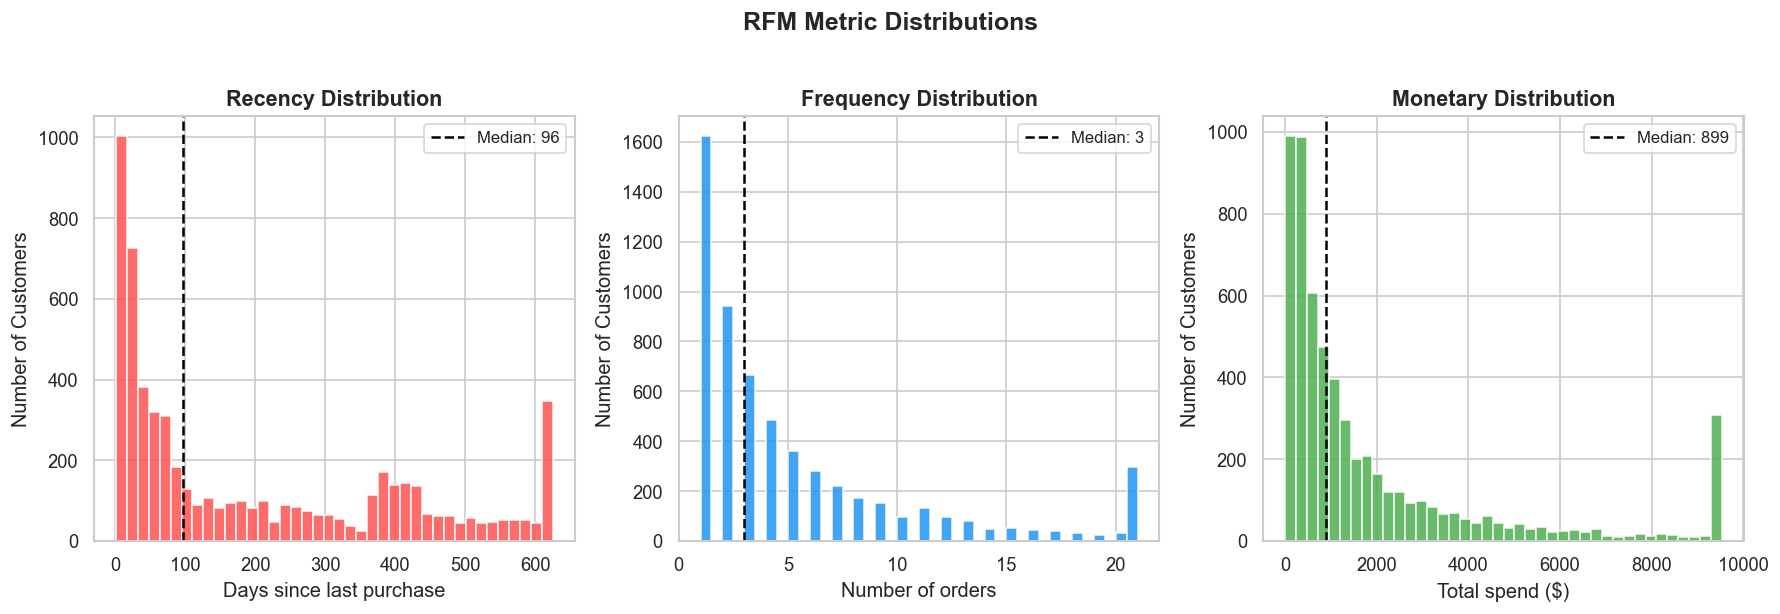

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#FF5252', '#2196F3', '#4CAF50']
metrics = ['Recency', 'Frequency', 'Monetary']
xlabels = ['Days since last purchase', 'Number of orders', 'Total spend ($)']

for ax, metric, color, xlabel in zip(axes, metrics, colors, xlabels):
    data = rfm[metric].clip(upper=rfm[metric].quantile(0.95))
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{metric} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of Customers')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.legend(fontsize=10)

plt.suptitle('RFM Metric Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/rfm_distributions.png', bbox_inches='tight')
plt.show()

## 7. K-Means Clustering

In [11]:
# Log transform to handle skewness
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print('Features scaled and log-transformed successfully!')

Features scaled and log-transformed successfully!


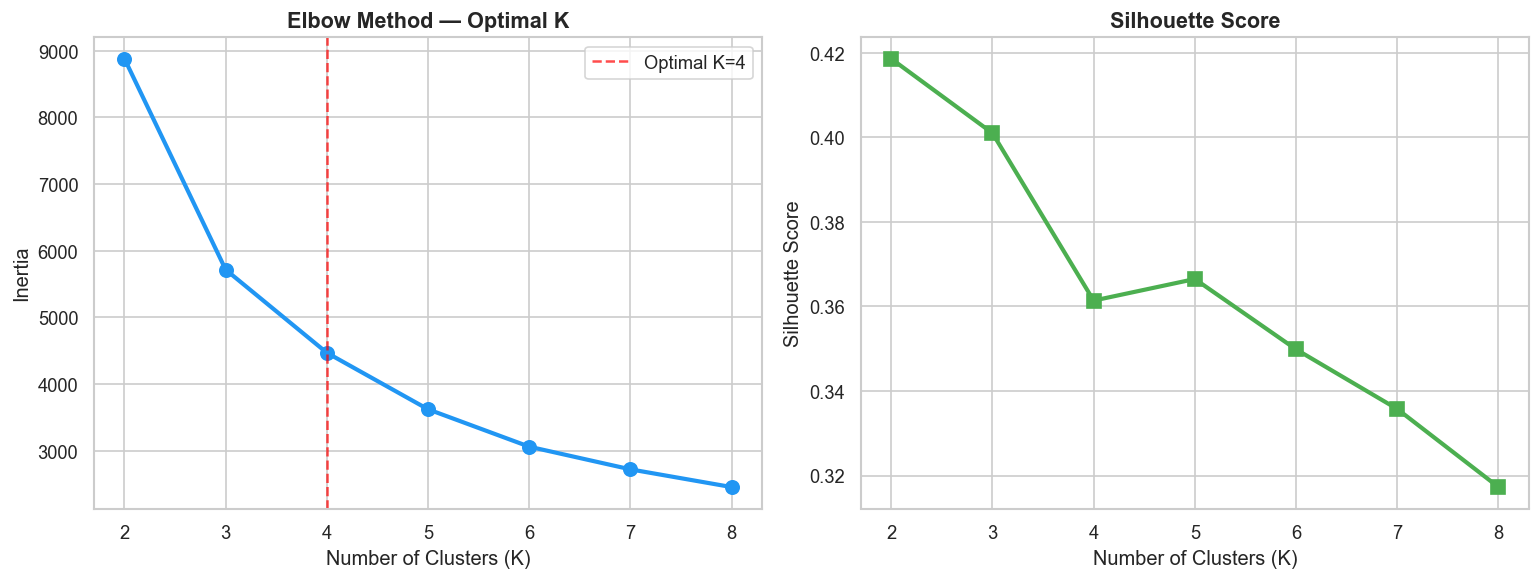

Best Silhouette Score at K=2: 0.4186


In [12]:
# Elbow method — find optimal k
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_range, inertias, marker='o', linewidth=2.5, color='#2196F3', markersize=8)
axes[0].set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
axes[0].legend()

axes[1].plot(k_range, silhouettes, marker='s', linewidth=2.5, color='#4CAF50', markersize=8)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../data/elbow_silhouette.png', bbox_inches='tight')
plt.show()

best_k = k_range[silhouettes.index(max(silhouettes))]
print(f'Best Silhouette Score at K={best_k}: {max(silhouettes):.4f}')

In [13]:
# Final K-Means model with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

print('K-Means clustering done!')
print(f'\nCustomers per cluster:')
print(rfm['Cluster'].value_counts().sort_index())

K-Means clustering done!

Customers per cluster:
Cluster
0    1638
1    1384
2    1891
3     965
Name: count, dtype: int64


## 8. Cluster Analysis & Naming

In [14]:
# Analyze cluster profiles
cluster_profile = rfm.groupby('Cluster').agg(
    Customers = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean')
).round(2)

print('Cluster Profiles:')
print(cluster_profile)

# Name clusters based on RFM values
segment_map = {}
for cluster in rfm['Cluster'].unique():
    profile = cluster_profile.loc[cluster]
    if profile['Avg_Recency'] < 50 and profile['Avg_Frequency'] > 5:
        segment_map[cluster] = 'Champions'
    elif profile['Avg_Monetary'] > cluster_profile['Avg_Monetary'].median() and profile['Avg_Frequency'] > 3:
        segment_map[cluster] = 'Loyal Customers'
    elif profile['Avg_Recency'] > 150:
        segment_map[cluster] = 'At-Risk Customers'
    else:
        segment_map[cluster] = 'Potential Loyalists'

rfm['Segment'] = rfm['Cluster'].map(segment_map)
print(f'\nSegment mapping: {segment_map}')
print(f'\nCustomers per segment:')
print(rfm['Segment'].value_counts())

Cluster Profiles:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0             1638       493.45           1.72        538.40
1             1384       106.20           1.73        425.75
2             1891        98.85           5.46       1909.99
3              965        42.74          22.20      13119.69

Segment mapping: {np.int32(3): 'Champions', np.int32(2): 'Loyal Customers', np.int32(0): 'At-Risk Customers', np.int32(1): 'Potential Loyalists'}

Customers per segment:
Segment
Loyal Customers        1891
At-Risk Customers      1638
Potential Loyalists    1384
Champions               965
Name: count, dtype: int64


In [15]:
# Segment profile summary
segment_summary = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(2)

segment_summary['Revenue_Pct'] = (segment_summary['Total_Revenue'] /
                                   segment_summary['Total_Revenue'].sum() * 100).round(1)

print('=== Customer Segment Summary ===')
print(segment_summary)

=== Customer Segment Summary ===
                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                    
At-Risk Customers         1638       493.45           1.72        538.40   
Champions                  965        42.74          22.20      13119.69   
Loyal Customers           1891        98.85           5.46       1909.99   
Potential Loyalists       1384       106.20           1.73        425.75   

                     Total_Revenue  Revenue_Pct  
Segment                                          
At-Risk Customers        881897.98          5.0  
Champions              12660496.08         71.4  
Loyal Customers         3611795.58         20.4  
Potential Loyalists      589239.52          3.3  


## 9. Visualizations

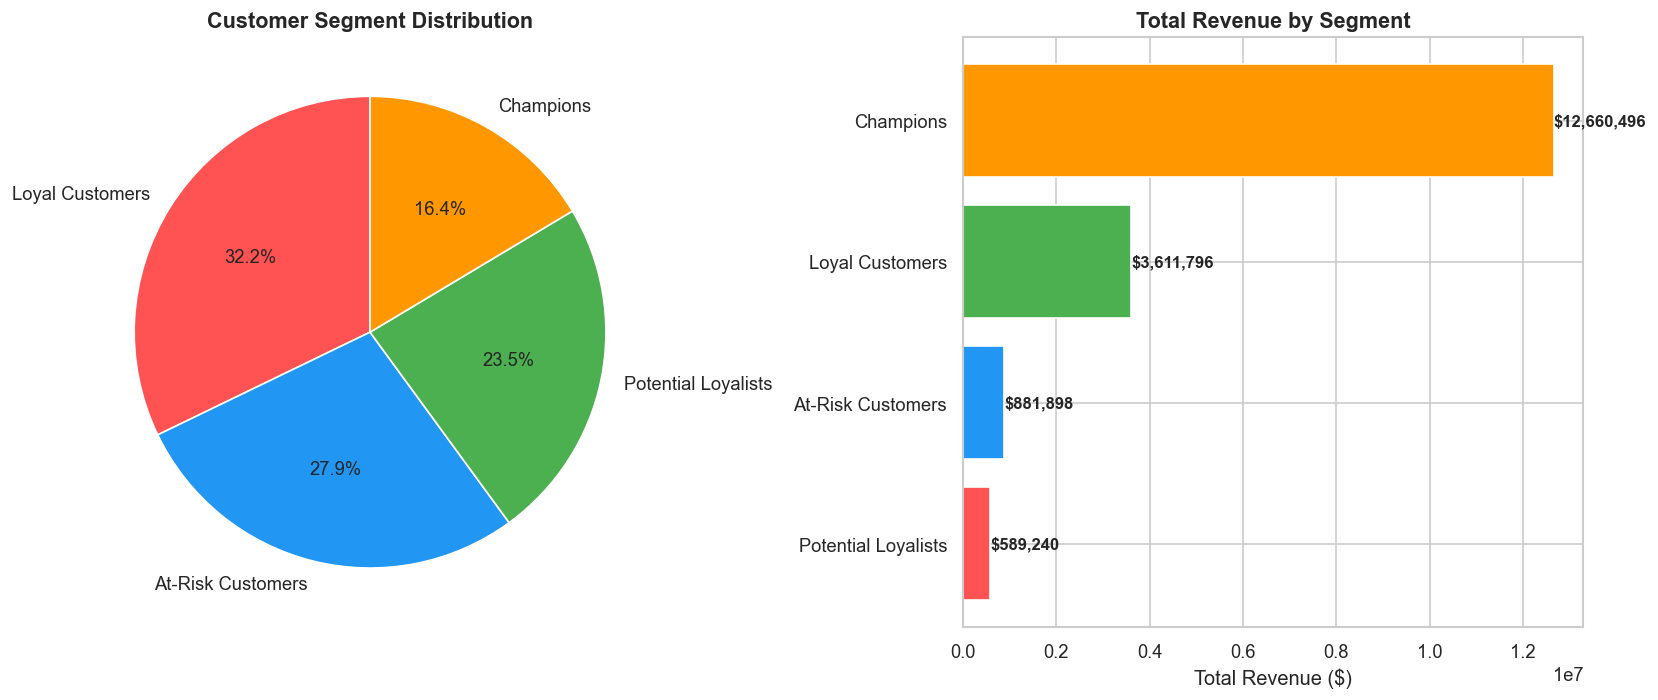

In [16]:
# Segment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

seg_counts = rfm['Segment'].value_counts()
colors = ['#FF5252', '#2196F3', '#4CAF50', '#FF9800']

# Pie chart
axes[0].pie(seg_counts, labels=seg_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Customer Segment Distribution', fontsize=13, fontweight='bold')

# Revenue by segment
rev_by_seg = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
bars = axes[1].barh(rev_by_seg.index, rev_by_seg.values,
                    color=colors[:len(rev_by_seg)], edgecolor='white')
axes[1].set_title('Total Revenue by Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
for bar, val in zip(bars, rev_by_seg.values):
    axes[1].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../data/segment_distribution.png', bbox_inches='tight')
plt.show()

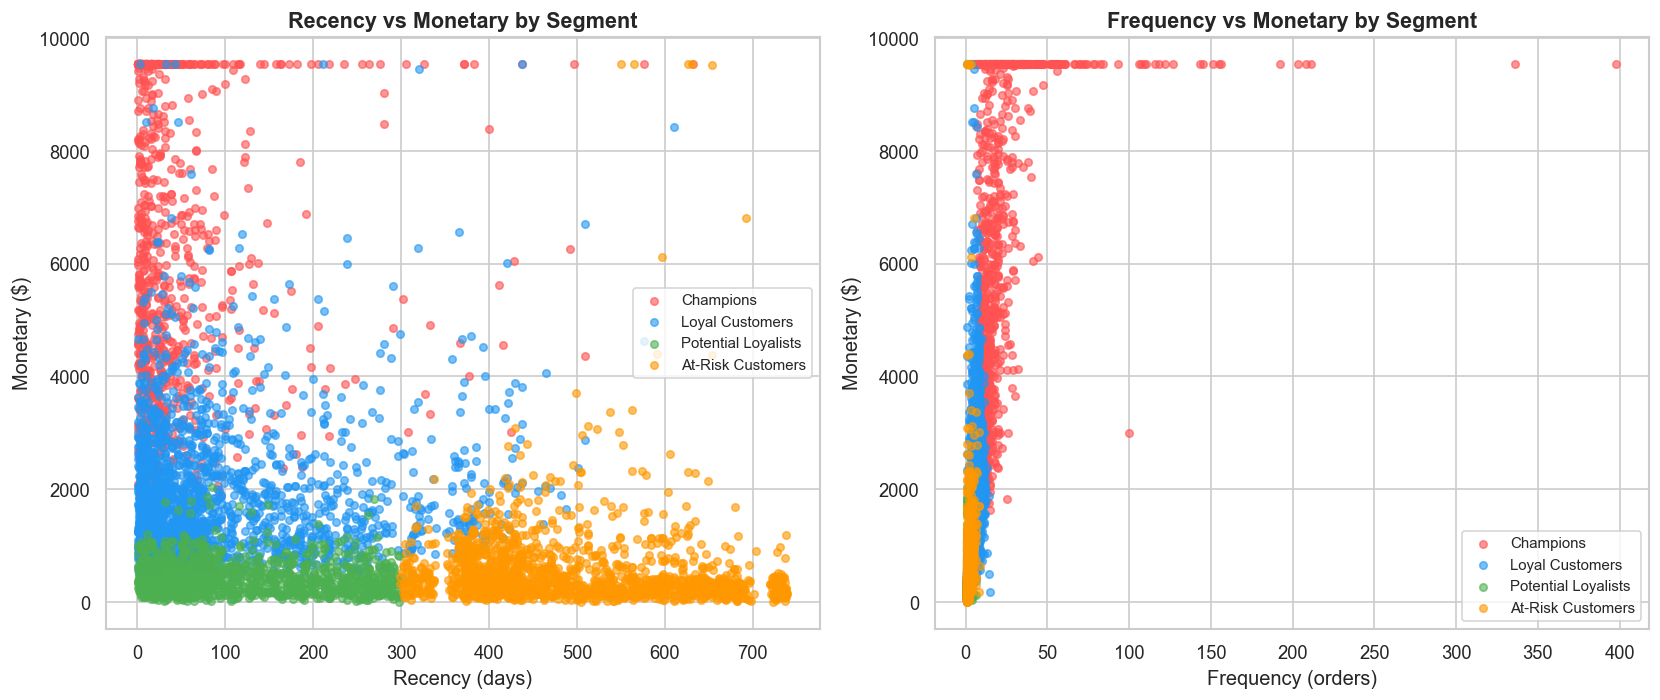

In [17]:
# RFM scatter plot — Recency vs Monetary colored by segment
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_colors = {
    'Champions': '#FF5252',
    'Loyal Customers': '#2196F3',
    'Potential Loyalists': '#4CAF50',
    'At-Risk Customers': '#FF9800'
}

# Recency vs Monetary
for seg, color in segment_colors.items():
    mask = rfm['Segment'] == seg
    if mask.sum() > 0:
        axes[0].scatter(rfm[mask]['Recency'],
                        rfm[mask]['Monetary'].clip(upper=rfm['Monetary'].quantile(0.95)),
                        c=color, label=seg, alpha=0.6, s=20)
axes[0].set_title('Recency vs Monetary by Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary ($)')
axes[0].legend(fontsize=9)

# Frequency vs Monetary
for seg, color in segment_colors.items():
    mask = rfm['Segment'] == seg
    if mask.sum() > 0:
        axes[1].scatter(rfm[mask]['Frequency'],
                        rfm[mask]['Monetary'].clip(upper=rfm['Monetary'].quantile(0.95)),
                        c=color, label=seg, alpha=0.6, s=20)
axes[1].set_title('Frequency vs Monetary by Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary ($)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/rfm_clusters.png', bbox_inches='tight')
plt.show()

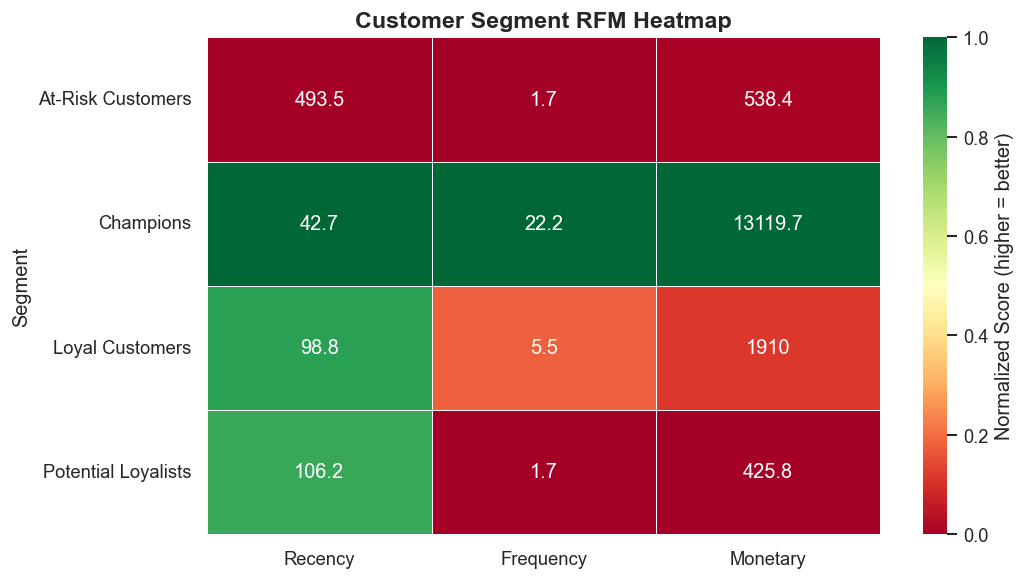

In [18]:
# Segment RFM heatmap
heatmap_data = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

# Normalize for heatmap
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
# Invert Recency — lower is better
heatmap_norm['Recency'] = 1 - heatmap_norm['Recency']

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(1), fmt='g',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Normalized Score (higher = better)'})
ax.set_title('Customer Segment RFM Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../data/rfm_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Export Data for Power BI

In [19]:
# Export RFM with segments for Power BI
rfm.to_csv('../data/rfm_segments.csv', index=False)
print('Exported: rfm_segments.csv')

# Export monthly revenue trend for Power BI
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M')).agg(
    Orders    = ('Invoice', 'nunique'),
    Customers = ('Customer ID', 'nunique'),
    Revenue   = ('Revenue', 'sum')
).reset_index()
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)
monthly['AOV'] = (monthly['Revenue'] / monthly['Orders']).round(2)
monthly.to_csv('../data/monthly_revenue.csv', index=False)
print('Exported: monthly_revenue.csv')

print('\nFiles ready for Power BI!')
print('Import rfm_segments.csv and monthly_revenue.csv into Power BI Desktop')

Exported: rfm_segments.csv
Exported: monthly_revenue.csv

Files ready for Power BI!
Import rfm_segments.csv and monthly_revenue.csv into Power BI Desktop


## 11. Key Findings & Campaign Targeting

In [20]:
print('=' * 55)
print('   CUSTOMER SEGMENTATION — FINAL RESULTS')
print('=' * 55)
print(f'  Total Transactions Analyzed : {len(df):,}')
print(f'  Total Unique Customers      : {rfm.shape[0]:,}')
print(f'  Clustering Algorithm        : K-Means (K=4)')
print()
for seg in rfm['Segment'].unique():
    count = (rfm['Segment'] == seg).sum()
    rev   = rfm[rfm['Segment'] == seg]['Monetary'].sum()
    print(f'  {seg:<22} : {count:>5} customers | ${rev:>12,.0f} revenue')
print('=' * 55)
print()
print('Campaign Targeting Strategies:')
print('  Champions          → Reward program, early access to new products')
print('  Loyal Customers    → Upsell premium plans, referral discounts')
print('  Potential Loyalists→ Onboarding offers, frequency incentives')
print('  At-Risk Customers  → Win-back campaigns, personalized discounts')

   CUSTOMER SEGMENTATION — FINAL RESULTS
  Total Transactions Analyzed : 805,549
  Total Unique Customers      : 5,878
  Clustering Algorithm        : K-Means (K=4)

  Champions              :   965 customers | $  12,660,496 revenue
  Loyal Customers        :  1891 customers | $   3,611,796 revenue
  At-Risk Customers      :  1638 customers | $     881,898 revenue
  Potential Loyalists    :  1384 customers | $     589,240 revenue

Campaign Targeting Strategies:
  Champions          → Reward program, early access to new products
  Loyal Customers    → Upsell premium plans, referral discounts
  Potential Loyalists→ Onboarding offers, frequency incentives
  At-Risk Customers  → Win-back campaigns, personalized discounts
